# Storm Events details, fatalities, and locations

NOAA's National Centers for Environmental Information (NCEI) keeps the Storm
Events Database: reports of significant weather since 1950, from tornadoes
and hail to floods, heat, and winter storms, compiled by National Weather
Service offices. NCEI publishes it as one gzipped CSV per year and table. One
row of the default details table is one event record: its type, county or
zone, local begin and end times, magnitude, injuries, deaths, damage, and a
narrative.

This walkthrough pulls the 2024 details file and looks at the tornado, hail,
and thunderstorm-wind reports that began in Oklahoma in May. It needs
`usdata[pandas]` and matplotlib; the download is about 13 MB and the run
takes under a minute.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-25T15:37:00+00:00
usdata 0.27.0; pandas 3.0.6


## Select

The manifest asks for May 2024, but NCEI serves whole years, so the query
selects the complete 2024 details file: every state, every event type, every
month. Location, variables, and other filters are rejected rather than
ignored; narrowing to Oklahoma and May happens after opening. The optional
`table` parameter would choose the fatalities or locations table instead of
details.

In [2]:
print(manifest.read_text())

name: oklahoma-storm-reports-may-2024
sources:
  - dataset: noaa:storm-events
    # Bulk access returns the entire 2024 details archive. Filter rows locally.
    start: 2024-05-01
    end: 2024-05-31



## What arrives

One compressed file. The name carries the data year (`d2024`) and NCEI's
creation date (`c...`); NCEI replaces the file with a newer creation date as
reports are revised, and the pull picks the newest one. The first pull writes
`dataset.lock.json` beside the manifest with that exact name and checksum, so
later pulls restore this revision instead of looking for a newer one.

In [3]:
result = pull(manifest)
(item,) = result.fetched
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)

File: StormEvents_details-ftp_v1.0_d2024_c20260728.csv.gz
Bytes: 12693243
Source: https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d2024_c20260728.csv.gz
Retrieved (UTC): 2026-09-25T15:37:01+00:00
Checksum: sha256:2070b83eccab041b36360ab73645b9a249c3eefc5b92b5b3fc0cbba4d9fcc09c


## Open

`open()` reads the gzip directly into a DataFrame; the cached file stays
compressed. The details table has over fifty columns, including two long
narratives, so `usecols` keeps only the ones used here. Identifier columns
(`EVENT_ID`, `EPISODE_ID`, `STATE_FIPS`, `CZ_FIPS`) stay strings.

Times are local standard time, labelled per row by `CZ_TIMEZONE` (`CST-6` is
UTC-6 all year, with no daylight saving). When `BEGIN_DATE_TIME`,
`END_DATE_TIME`, and `CZ_TIMEZONE` are kept, `open()` adds `BEGIN_UTC` and
`END_UTC` and records the rule in the frame's attributes. Place is the county
or zone (`CZ_TYPE`, `CZ_FIPS`, `CZ_NAME`) plus begin and end coordinates.

`MAGNITUDE` changes meaning with the event type: hail diameter in inches,
thunderstorm-wind speed in knots (`MAGNITUDE_TYPE` `EG` estimated, `MG`
measured), and nothing for tornadoes, whose rating is `TOR_F_SCALE`.

In [4]:
columns = [
    "EVENT_ID",
    "EPISODE_ID",
    "STATE",
    "CZ_TYPE",
    "CZ_FIPS",
    "CZ_NAME",
    "EVENT_TYPE",
    "BEGIN_YEARMONTH",
    "BEGIN_DAY",
    "BEGIN_DATE_TIME",
    "END_DATE_TIME",
    "CZ_TIMEZONE",
    "MAGNITUDE",
    "MAGNITUDE_TYPE",
    "TOR_F_SCALE",
    "BEGIN_LAT",
    "BEGIN_LON",
]
frame = item.open_csv(usecols=columns)
types = ["Hail", "Thunderstorm Wind", "Tornado"]
may = frame[
    frame["STATE"].eq("OKLAHOMA")
    & frame["BEGIN_YEARMONTH"].eq(202405)
    & frame["EVENT_TYPE"].isin(types)
].copy()
print(f"{len(frame)} rows in the 2024 file; {len(may)} Oklahoma May rows of these types")
print("Time-zone labels:", sorted(may["CZ_TIMEZONE"].unique()))
print("Record types:", may["CZ_TYPE"].value_counts().to_dict())
print("Distinct events:", may["EVENT_ID"].nunique(), "in", may["EPISODE_ID"].nunique(), "episodes")
crossed = (may["BEGIN_UTC"].dt.day != may["BEGIN_DAY"]).sum()
print(f"Rows whose UTC date differs from the reported local date: {crossed}")
shown = ["EVENT_ID", "EVENT_TYPE", "CZ_NAME", "BEGIN_DATE_TIME", "BEGIN_UTC", "MAGNITUDE"]
may[shown].head()

69801 rows in the 2024 file; 589 Oklahoma May rows of these types
Time-zone labels: ['CST-6']
Record types: {'C': 589}
Distinct events: 589 in 32 episodes
Rows whose UTC date differs from the reported local date: 279


,EVENT_ID,EVENT_TYPE,CZ_NAME,BEGIN_DATE_TIME,BEGIN_UTC,MAGNITUDE
256,1178562,Hail,LINCOLN,06-MAY-24 22:27:00,2024-05-07 04:27:00+00:00,1.75
15716,1222698,Thunderstorm Wind,KINGFISHER,06-MAY-24 19:59:00,2024-05-07 01:59:00+00:00,56.00
16029,1222697,Thunderstorm Wind,NOBLE,06-MAY-24 19:14:00,2024-05-07 01:14:00+00:00,54.00
16743,1222699,Thunderstorm Wind,KINGFISHER,06-MAY-24 20:19:00,2024-05-07 02:19:00+00:00,51.00
16744,1222700,Thunderstorm Wind,CUSTER,19-MAY-24 18:59:00,2024-05-20 00:59:00+00:00,66.00


Nearly half the rows start on a different UTC date than the local one,
because Oklahoma's storms peak in the evening, after 18:00 CST. Group by the
local date, as here, to count storm days; convert to UTC before joining to
radar, satellite, or model data.

## A first look

Reports per local day through May, stacked by type. Each bar counts event
records, not storms: one storm can leave hail, wind, and tornado rows, and a
tornado crossing a county line leaves one row per county.

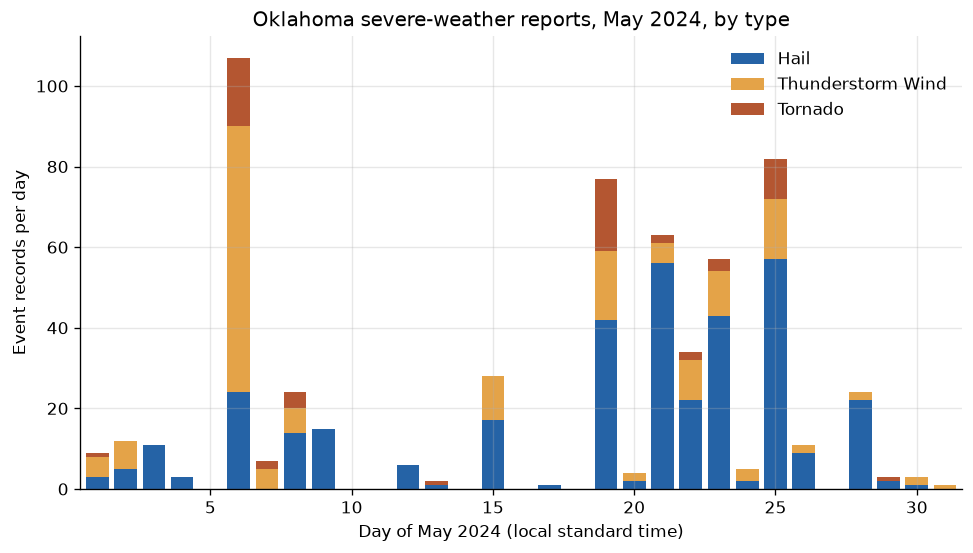

In [5]:
daily = (
    may.groupby([may["BEGIN_DAY"], "EVENT_TYPE"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(1, 32), columns=types, fill_value=0)
)
colors = {"Hail": "#2563a6", "Thunderstorm Wind": "#e4a348", "Tornado": "#b45631"}
fig, ax = plt.subplots(layout="constrained")
bottom = pd.Series(0, index=daily.index)
for kind in types:
    ax.bar(daily.index, daily[kind], bottom=bottom, color=colors[kind], label=kind)
    bottom += daily[kind]
ax.set_xlabel("Day of May 2024 (local standard time)")
ax.set_ylabel("Event records per day")
ax.set_title("Oklahoma severe-weather reports, May 2024, by type")
ax.set_xlim(0.4, 31.6)
ax.legend(frameon=False)
plt.show()

In [6]:
totals = daily.sum(axis=1)
busiest = totals.nlargest(5)
print(f"{int(totals.gt(0).sum())} of 31 days had at least one report")
print("Busiest days:", ", ".join(f"{day} May ({count})" for day, count in busiest.items()))
print(f"Share of the month's records on those five days: {busiest.sum() / totals.sum():.0%}")
tornadoes = may[may["EVENT_TYPE"].eq("Tornado")]
print("\nTornado records by rating:")
print(tornadoes["TOR_F_SCALE"].value_counts().sort_index().to_string())

24 of 31 days had at least one report
Busiest days: 6 May (107), 25 May (82), 19 May (77), 21 May (63), 23 May (57)
Share of the month's records on those five days: 66%

Tornado records by rating:
TOR_F_SCALE
EF0    17
EF1    26
EF2     5
EF3     2
EF4     1
EFU    10


The month's reports cluster on a few outbreak days: five of them hold two
thirds of the records. 6 May, the day of
the Osage County EF4, has the most thunderstorm-wind rows of the month, and
the last two weeks bring day after day of hail. `EFU` is NCEI's code for
a tornado that could not be rated, so it stays its own category rather than a
missing value. Ratings come from damage surveys; they are not measured winds.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. Keep the
manifest and lockfile with your analysis; the citation below is what a
methods section needs, and `usdata cite dataset.yaml` prints the same.

In [7]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:storm-events
  NOAA National Centers for Environmental Information, Storm Events Database, accessed via usdata
  homepage: https://www.ncei.noaa.gov/access/storm-events-database/
  license: US Government Work (public domain)
  terms: https://www.ncei.noaa.gov/metadata/geoportal/rest/metadata/item/gov.noaa.ncdc:C00510/html
  retrieved: 2026-09-25; 1 checksummed asset (12,693,243 bytes) pinned by usdata 0.27.0
  sources: 1


## What was awkward

- A month of one state costs the whole year's file for the whole country,
  about 13 MB compressed and seventy thousand rows. There is no server-side
  subset, so every query filters locally.
- `MAGNITUDE` holds inches for hail, knots for wind, and nothing for
  tornadoes; the unit is implied by `EVENT_TYPE`, not stated in the file.
- Rows count reports, not storms. A tornado that crosses a county line is
  two rows, and one storm is often hail, wind, and tornado rows in one
  `EPISODE_ID`, so the unit of counting has to be chosen before aggregating.
- `BEGIN_UTC` only appears if `usecols` keeps both date-time columns and
  `CZ_TIMEZONE`; drop one and the conversion silently does not happen.
- `DAMAGE_PROPERTY` and `DAMAGE_CROPS` are text such as `10.00K`, with
  magnitude suffixes and blanks, so this walkthrough does not sum damage.
- A missing report does not mean nothing happened, and reporting practice
  has changed over the decades. The
  [Storm Events guide](https://docs.usdata.dev/providers/noaa-storm-events/)
  and [severe weather labels guide](https://docs.usdata.dev/guides/severe-weather-labels/)
  cover revisions, time zones, and these limits.